# GPU programming is cost-model first

A 1-hour course for database & systems researchers. One thesis, proven by measurement on the hardware in front of us:

> **You don't pick an algorithm and then make the chip run it. You compute the cost model first -- bytes moved, passes over memory, latency vs concurrency, where the data lives, how you access it -- and *that* selects the algorithm before you write a line.** Asymptotic optimality is not hardware-neutral; "best" is a function of the chip.

**The chip:** a single **RTX 6000 Ada** (sm_89, AD102) -- 48 GB **GDDR6** ~960 GB/s, **96 MB L2**, register file ~36 MB. It is two things at once: a **bandwidth machine** (huge throughput, but only if you keep it fed) and a **latency-hiding concurrency machine** (per-access latency is *bad*; throughput comes from running thousands of warps so a stall in one is covered by another). GPU programming is therefore not only **parallel** -- it's **concurrent**: latency forces you to always have other work in flight.

**The spine:** two sorts tell the rest of the story from two angles -- **radix** = *massive parallelism collapses the algorithm; linear-time wins*, **merge** = *the cache / access-pattern / memory-hierarchy story* -- and a production library is just a **frozen cost-model decision tree** that picks between them for you.

## Time budget -- 1 hour (~51 min content + ~5 Q&A)

| # | section | min |
|---|---|---|
| 0 | Thesis + hardware | 3 |
| 1 | Bandwidth identity | 4 |
| 2 | **Latency & how the GPU hides it** (concurrency) | 6 |
| 3 | Cache cliff (measure at GB) | 4 |
| 4 | **Cost model in two lines** (thrust dispatch) | 5 |
| 5 | Two sorts (framing) | 2 |
| 5a | Radix: passes-law + 4x merge | 9 |
| 5b | Merge: hierarchy + ablation | 9 |
| 6 | Kernel is ~10% (rug pull) | 6 |
| 7 | Closing | 3 |
| - | Q&A | 5 |

(SASS-diff and histogram sections were cut for time; they live in the repo as
supporting material.)

## How to read this hour: it's a guessing game

Each section pits two pieces of code and asks **which is faster, and by how much** -- then we run it, live. You will guess wrong, often, and every miss *is* the lesson: on a GPU you cannot eyeball performance; you compute the cost model.

Some demos (the pointer `chase`) are deliberate **golf** -- useless functions that isolate exactly one mechanism so you can see it in the clear. You will never write them. But you cannot *read* the code you actually ship -- GEMM, CUB's merge and radix -- without them, because that code is loops-over-loops, unrolled and register-blocked everywhere, and every line is one of these tradeoffs. **The first half builds the vocabulary; the second half spends it.**

In [1]:
%matplotlib inline
import subprocess, re, os
import matplotlib.pyplot as plt

ROOT = os.getcwd()
GPU, CPU, RADIX, MERGE, INK, CEIL = "#76b900", "#5b6770", "#0b84a5", "#c0392b", "#23272b", "#b9bfc4"
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#eef1f3", "axes.axisbelow": True})

def sh(cmd, cwd=None, timeout=900):
    r = subprocess.run(cmd, shell=True, cwd=cwd or ROOT, capture_output=True, text=True, timeout=timeout)
    return r.stdout + r.stderr

def grab(text, pat):
    m = re.search(pat, text); return float(m.group(1)) if m else float("nan")

sh("make -s -C demo1_bandwidth; make -s -C demo2_sort; make -s -C demo3_rugpull")
sh("cd demo6_mergesort && nvcc -O3 -std=c++17 -arch=sm_89 -o cub_compare cub_compare.cu && "
   "nvcc -O3 -std=c++17 -arch=sm_89 -o thrust_compare thrust_compare.cu")
sh("cd demo7_latency && nvcc -O3 -std=c++17 -arch=sm_89 -o latency latency.cu")
print("built.")

built.


## 1. The chip's identity is bandwidth  (~4 min)

> **Demo** `demo1_bandwidth` &middot; **in:** one ~1 GB array &middot; **out:** achieved GB/s &middot; **algorithm:** trivial vectorized streaming copy `out[i]=in[i]` (GPU) and STREAM Triad `a=b+s*c` (CPU) &middot; **why:** the simplest possible kernel, so the only thing measured is the bus -- it establishes bandwidth as the chip's identity.

A trivial streaming copy. The CPU's STREAM Triad tops out well below its (small) DRAM peak; the GPU's copy kernel saturates its (much larger) bus. The story is the *ratio*, and that the GPU number comes from a kernel you could write in your sleep.

```cpp
// float4 = 16 B/thread, fully coalesced, grid-stride
__global__ void copy(float4* out, const float4* in, size_t n) {
  for (size_t i = blockIdx.x*blockDim.x + threadIdx.x; i < n;
       i += gridDim.x*blockDim.x)            // every thread strides the array
    out[i] = in[i];
}
```

**Guess first** 🎲 -- GPU streaming copy vs CPU STREAM Triad: how many times faster? Write a number.

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>GPU copy (independent loads)</b><pre>__global__ void copy(float4* o,
          const float4* in, size_t n){
  for(size_t i=tid;i&lt;n;i+=stride)
    o[i] = in[i];
}</pre></td><td style="width:50%;vertical-align:top"><b>CPU STREAM Triad</b><pre>#pragma omp parallel for
for(size_t i=0;i&lt;n;i++)
  a[i] = b[i] + s*c[i];</pre></td></tr></table>

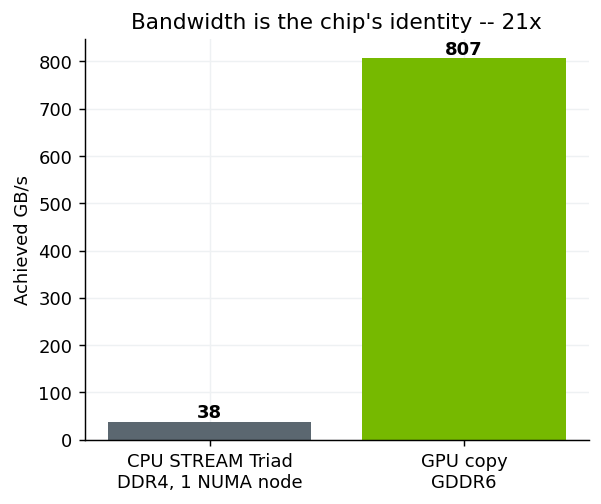

In [2]:
g = grab(sh("./stream_gpu", cwd=f"{ROOT}/demo1_bandwidth"), r"copy kernel:\s*([\d.]+)")
numa = "numactl --cpunodebind=0 --membind=0 " if sh("which numactl").strip() else ""
c = grab(sh(f"OMP_NUM_THREADS=6 OMP_PROC_BIND=close OMP_PLACES=cores {numa}./stream_cpu",
            cwd=f"{ROOT}/demo1_bandwidth"), r"triad bandwidth:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["CPU STREAM Triad\nDDR4, 1 NUMA node", "GPU copy\nGDDR6"], [c, g], color=[CPU, GPU])
ax.set_ylabel("Achieved GB/s"); ax.set_title(f"Bandwidth is the chip's identity -- {g/c:.0f}x")
for i, v in enumerate([c, g]): ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## 2. The hidden half: latency, and why "18k cores" is a lie  (~6 min)

> **Demo** `demo7_latency` &middot; **in:** a 1 GB int array wired as one random permutation cycle &middot; **out:** raw latency, single-SM throughput vs warps (against the SM's issue width), and warps/SM vs register usage &middot; **algorithm:** per-thread dependent-load pointer chase on ONE SM, swept 1..32 warps, then register-heavy variants &middot; **why:** *prove* that latency hiding via oversubscription -- not "more cores" -- is the engine, and that the parallelism is *occupancy*, set by registers.

One thread chasing dependent loads to HBM waits ~230 ns / ~580 cycles. **One thread is slow** -- the GPU's per-access latency is *worse* than a CPU cache.

**What `chase` is doing, and why.** `next[]` is a random permutation wired into one giant cycle through the 1 GB array; each thread just runs `idx = next[idx]` over and over. The whole trick is that one line: the *address* of each load is the *value* the previous load returned, so the loads **cannot overlap** -- the hardware can't issue the next until the last comes back, and every access pays the full round-trip to HBM. That makes it a **latency thermometer**: the copy kernel was the opposite (independent loads, hundreds in flight -> *bandwidth*); a dependency chain has one load outstanding per thread -> *latency*. It's the one workload where latency-hiding has nothing to hide, so the raw ~230 ns shows -- then we add warps and watch the hiding switch back on. (The random *cycle*, not just random indices, is deliberate: it never short-loops and always misses the 96 MB L2. The `r[K]` registers are unrelated -- just a knob to lower occupancy for Part C.)

**Where you've already met this pattern:** a linked-list walk *is* `chase`; so is the *core* of a **graph traversal**, a **B-tree index lookup**, a **hash-join probe** -- read a value, and it tells you the next address. All of them are data-dependent, un-prefetchable, **latency-bound** access: the opposite end of the cost model from streaming. (We are *not* building a graph algorithm -- the branching and frontier machinery would bury the lesson; we keep the access pattern and drop everything else.) Which is why those DB / graph workloads live or die on the latency hiding we measure next.

Now the proof, on **one SM** so it can't be "use more cores": an Ada SM has just **4 warp schedulers** -- it can *issue* only 4 warps per clock (128 FP32 lanes = 4 warps of SIMD). If warps were cores, throughput would flatten at 4. **It doesn't.** Oversubscribe the *same* SM to 8, 16, 32 warps and throughput keeps climbing -- **32 warps (8x oversubscribed) is ~5x faster than at 4.** Those extra warps cannot be computing (there are only 4 slots); they are covering each other's 580-cycle stalls. **Warps are latency-hiding tasks you oversubscribe, not cores.**

So "18,176 CUDA cores" is not 18,176 CPUs -- it's SIMD lanes. The real parallelism is how many *warps* you keep resident = **occupancy** = register-file / (regs/thread x 32). A register-heavy kernel fits fewer warps -- and Part C **measures** the cost: 148 regs/thread caps it at **8 warps/SM**, and the *same* chase run at 8 warps is **2.7x slower** on one SM, purely from lost occupancy (the compute confound removed by measuring the light kernel at each capped warp count). That number is visible only in **`ptxas -v`** and the **profiler** -- which is why you need them.

```cpp
// each thread chases its own dependent-load cycle: latency-bound, nothing hides it
template <int K> __global__ void chase(const int* next, size_t N, int steps, int* sink) {
  size_t idx = (threadIdx.x * 2654435761ull) % N;
  int r[K];                                  // K live registers -> controls occupancy
  for (int i=0;i<steps;++i){ idx = next[idx]; for(int k=0;k<K;++k) r[k]^=(int)idx; }
}
chase<1><<<1, 32*W>>>(...);   // ONE block = ONE SM (4 schedulers); sweep W = 1..32 warps
```

**Guess first** 🎲 -- it's a *single SM* (it can issue only 4 warps/clock). Going 1 -> 32 warps on it: flat, or faster? by how much?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>1 warp on ONE SM</b><pre>chase&lt;1&gt;&lt;&lt;&lt;1,   32&gt;&gt;&gt;(...);</pre></td><td style="width:50%;vertical-align:top"><b>32 warps on the SAME SM</b><pre>chase&lt;1&gt;&lt;&lt;&lt;1, 1024&gt;&gt;&gt;(...);</pre></td></tr></table>

*(identical kernel -- only the launch width changes)*

Chip: 142 SMs x 128 FP32 lanes = 18176 "CUDA cores".
Per SM: 4 warp schedulers -> it can ISSUE only 4 warps per clock (128 lanes = 4 warps of SIMD). Naively, '4 things at once'.
Yet it holds up to 48 warps resident. Why so many more than it can run?

Part A  one thread, dependent loads: 232 ns/access (~582 cycles). one thread is slow.

Part B  ONE SM (single block), add warps past the 4 schedulers it can issue:
  warps  oversub   Maccess/s   speedup
     1      0x         116.6     1.0x
     2      0x         205.7     1.8x
     4      1x         399.7     3.4x
     8      2x         768.8     6.6x
    16      4x        1443.6     12.4x
    32      8x        2111.3     18.1x
  -> 4 warps already fills the 4 schedulers; 32 warps (8x oversubscribed) is 5.3x FASTER.
     Those extra warps cannot be using cores -- there are only 4 -- they are
     hiding the 582-cycle latency. Warps are TASKS you oversubscribe, not cores.


Part C  registers -> occupancy -> (measured) latency hiding on one

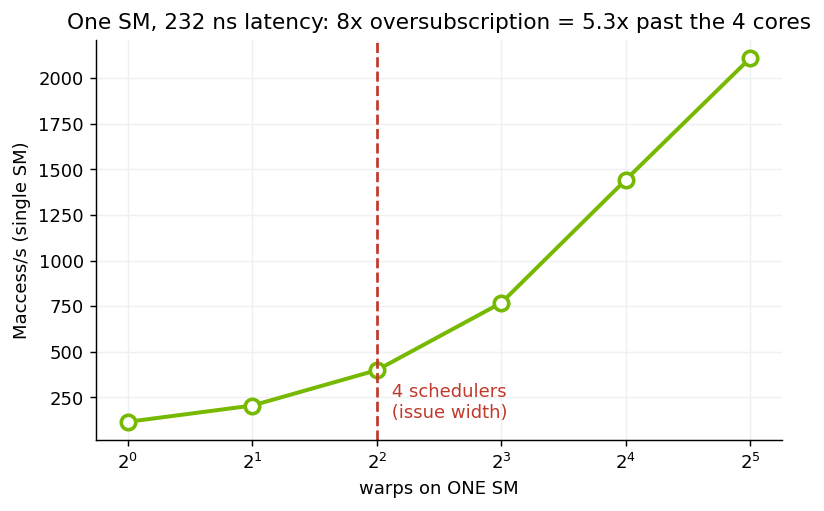

In [3]:
out = sh("./latency", cwd=f"{ROOT}/demo7_latency"); print(out)
lat = grab(out, r"([\d.]+)\s*ns/access")
rows = re.findall(r"^\s*(\d+)\s+[\d.]+x\s+([\d.]+)\s+[\d.]+x\s*$", out, re.M)
warps = [int(a) for a, _ in rows]; thru = [float(b) for _, b in rows]
fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(warps, thru, "o-", color=GPU, lw=2.2, ms=8, mfc="white", mew=2)
ax.axvline(4, ls="--", color=MERGE); ax.text(4.2, thru[0], " 4 schedulers\n (issue width)", color=MERGE, va="bottom")
ax.set_xscale("log", base=2); ax.set_xlabel("warps on ONE SM"); ax.set_ylabel("Maccess/s (single SM)")
over = (thru[-1]/thru[2]) if len(thru) > 2 else 0    # 32 warps vs 4 warps
ax.set_title(f"One SM, {lat:.0f} ns latency: 8x oversubscription = {over:.1f}x past the 4 cores")
plt.show()

## 3. ...and the cache hides it too -- so measure at GB scale  (~4 min)

> **Demo** `demo2_sort/v0_naive` &middot; **in:** 2^24..2^27 random int32 keys &middot; **out:** sort throughput vs array size &middot; **algorithm:** naive bitonic sort (one global-memory kernel per compare-swap stage) &middot; **why:** the same kernel across sizes exposes the L2 cliff -- proof a sub-cache benchmark lies, so measure at >= 1 GB.

Run the *same naive sort kernel* across sizes. Below 96 MB the array lives in L2 and throughput is ~4x higher than reality; cross the L2 and you fall off a cliff to true HBM-bound speed. **Any benchmark that fits in cache is lying to you** -- everything past here runs at >= 1 GB.

```cpp
// naive bitonic: one kernel launch PER stage, every compare-swap hits global memory
__global__ void stage(int* a, int n, int j, int k) {
  int i = blockIdx.x*blockDim.x + threadIdx.x, ixj = i ^ j;
  if (ixj > i) {
    bool asc = (i & k) == 0;
    if ((a[i] > a[ixj]) == asc) { int t=a[i]; a[i]=a[ixj]; a[ixj]=t; }
  }
}
```

**Guess first** 🎲 -- the *same* sort kernel on 64 MB vs 256 MB of keys: same throughput, or not? and why would it differ?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>64 MB (fits in 96 MB L2)</b><pre>bitonic_sort(d, 1&lt;&lt;24);</pre></td><td style="width:50%;vertical-align:top"><b>256 MB (exceeds L2)</b><pre>bitonic_sort(d, 1&lt;&lt;26);</pre></td></tr></table>

*(identical kernel -- only the array size changes)*

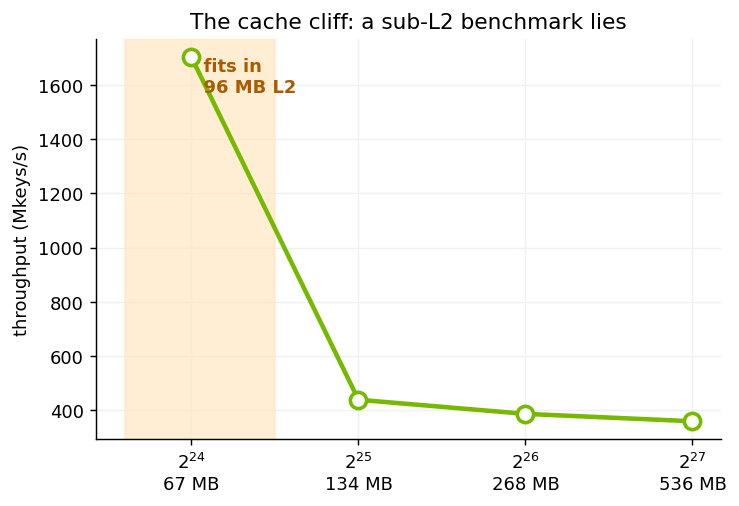

In [4]:
sizes = [24, 25, 26, 27]
mk = [grab(sh(f"./v0_naive {s} 5", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*Mkeys/s") for s in sizes]
fig, ax = plt.subplots(figsize=(6.2, 4)); x = range(len(sizes))
ax.plot(x, mk, "o-", color=GPU, lw=2.5, ms=9, mfc="white", mew=2)
ax.axvspan(-0.4, 0.5, color="#ffe7c2", alpha=0.7)
ax.text(0, mk[0], "  fits in\n  96 MB L2", va="top", color="#a85b00", fontweight="bold")
ax.set_xticks(list(x)); ax.set_xticklabels([f"$2^{{{s}}}$\n{2**s*4//10**6} MB" for s in sizes])
ax.set_ylabel("throughput (Mkeys/s)"); ax.set_title("The cache cliff: a sub-L2 benchmark lies")
plt.show()

## 4. The cost model, in two lines of user code  (~5 min, the hook)

> **Demo** `demo6_mergesort/thrust_compare` &middot; **in:** 2^28 random int32 &middot; **out:** runtime of `thrust::sort` with a default vs a custom comparator &middot; **algorithm:** `thrust::sort`, which dispatches to radix or merge by key/comparator *type* &middot; **why:** the cost-model decision is already baked into the highest-level API -- the hook.

The highest-level GPU sort API -- `thrust::sort` -- *already* embodies the thesis. Its dispatch (`thrust/system/cuda/detail/sort.h`, `can_use_primitive_sort`) picks at **compile time**:

```cpp
// arithmetic key (int/float...) AND default less/greater  -> RADIX  (cub::DeviceRadixSort)
// custom comparator, or non-arithmetic key                -> MERGE  (cub::DeviceMergeSort)
```

These two calls sort the *same data into the same order* -- the only difference is a comparator whose type happens to mean `a < b` -- yet one is several times slower, because its type blocks the radix path. **The cost model, triggered by a type, invisible to the user.**

```cpp
struct MyLess { __device__ bool operator()(int a, int b) const { return a < b; } };

thrust::sort(d.begin(), d.end());             // -> radix  (arithmetic key + default less)
thrust::sort(d.begin(), d.end(), MyLess());   // -> merge  (custom comparator TYPE blocks radix)
```

**Guess first** 🎲 -- `thrust::sort(x)` vs `thrust::sort(x, MyLess())`. Same data, same ascending order, a comparator that *means* `a < b`. Same speed? If not, which way, and how much?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>thrust::sort(x)</b><pre>thrust::sort(d.begin(), d.end());</pre></td><td style="width:50%;vertical-align:top"><b>thrust::sort(x, MyLess())</b><pre>struct MyLess {
  bool operator()(int a,int b){return a&lt;b;}
};
thrust::sort(d.begin(), d.end(), MyLess());</pre></td></tr></table>

n=2^28 (268M keys)
  thrust::sort(x)           -> radix :   18.879 ms  [PASS]
  thrust::sort(x, MyLess()) -> merge :   54.577 ms  [PASS]
  one custom comparator cost you 2.9x -- the cost model, by type.



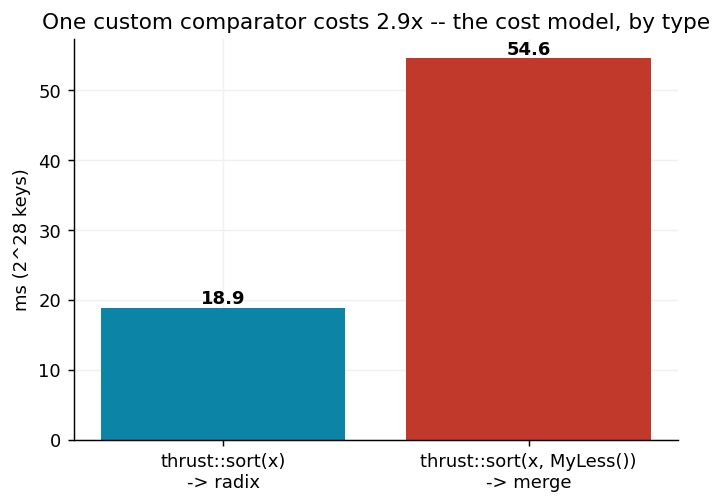

In [5]:
out = sh("./thrust_compare 28 6", cwd=f"{ROOT}/demo6_mergesort"); print(out)
r = grab(out, r"-> radix :\s*([\d.]+)"); m = grab(out, r"-> merge :\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["thrust::sort(x)\n-> radix", "thrust::sort(x, MyLess())\n-> merge"], [r, m], color=[RADIX, MERGE])
ax.set_ylabel("ms (2^28 keys)"); ax.set_title(f"One custom comparator costs {m/r:.1f}x -- the cost model, by type")
for i, v in enumerate([r, m]): ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## 5. Two sorts, two truths about the chip  (framing ~2 min)

Why ship *both*? Because there's no single best sort -- the cost model picks the game. The two algorithms illuminate the two halves of "what is a GPU."

### 5a. Radix -- *massive parallelism collapses the algorithm; linear time wins*  (~9 min)

> **Demo** `demo2_sort` (v0->v4) + `demo6_mergesort/cub_compare` &middot; **in:** 2^26 / 2^28 random int32 &middot; **out:** per-version runtime; CUB merge vs radix at 1 GB &middot; **algorithm:** the bitonic optimization arc ending in CUB radix, then radix vs a fully-tuned CUB merge &middot; **why:** hand-tuning a comparison sort has a ceiling; on a bandwidth machine the linear-pass algorithm (radix) wins.

On a CPU you're taught O(n log n) comparison sort is optimal and you ignore radix for its constants. The GPU inverts the cost model: with near-perfect data-parallelism the per-element work is free, so **only passes over memory count** -- and O(n)-pass radix beats O(n log n) merge. The naive-to-radix arc (bitonic is just the bad global-memory baseline that motivates it), then radix vs a *fully optimized* CUB merge at GB scale.

```cpp
// production radix is two lines: ask for scratch, then sort
size_t bytes = 0;
cub::DeviceRadixSort::SortKeys(nullptr,  bytes, d_in, d_out, n);
cudaMalloc(&d_temp, bytes);
cub::DeviceRadixSort::SortKeys(d_temp, bytes, d_in, d_out, n);
```

**Guess first** 🎲 -- a *world-class* comparison sort (CUB merge) vs CUB radix, both at 1 GB: which wins, and by how much?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>CUB merge (comparison)</b><pre>cub::DeviceMergeSort::SortKeys(
   tmp, sz, d, n, less);</pre></td><td style="width:50%;vertical-align:top"><b>CUB radix</b><pre>cub::DeviceRadixSort::SortKeys(
   tmp, sz, d_in, d_out, n);</pre></td></tr></table>

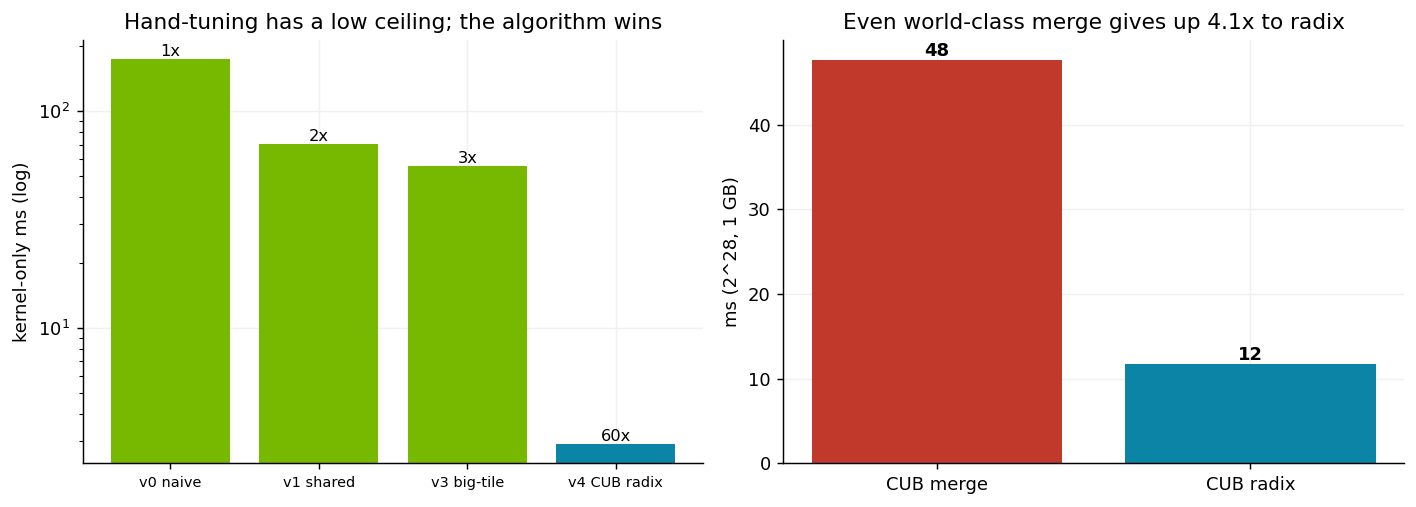

In [6]:
ARC = [("v0_naive","v0 naive"),("v1_shared","v1 shared"),("v3_multiblock","v3 big-tile"),("v4_cub","v4 CUB radix")]
ms = {lbl: grab(sh(f"./{b} 26 10", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*ms") for b, lbl in ARC}
base = ms["v0 naive"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
bars = a1.bar(list(ms), list(ms.values()), color=[GPU, GPU, GPU, RADIX]); a1.set_yscale("log")
a1.set_ylabel("kernel-only ms (log)"); a1.set_title("Hand-tuning has a low ceiling; the algorithm wins")
for b, v in zip(bars, ms.values()): a1.text(b.get_x()+b.get_width()/2, v, f"{base/v:.0f}x", ha="center", va="bottom", fontsize=9)
a1.tick_params(axis="x", labelsize=8)
out = sh("./cub_compare 28 6", cwd=f"{ROOT}/demo6_mergesort")
cm = grab(out, r"merge sort :\s*([\d.]+)"); cr = grab(out, r"radix sort :\s*([\d.]+)")
a2.bar(["CUB merge", "CUB radix"], [cm, cr], color=[MERGE, RADIX]); a2.set_ylabel("ms (2^28, 1 GB)")
a2.set_title(f"Even world-class merge gives up {cm/cr:.1f}x to radix")
for i, v in enumerate([cm, cr]): a2.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()

### 5b. Merge -- the on-chip memory lever: register blocking  (~9 min)

> **Demo** `demo6_mergesort/merge_ablation` &middot; **in:** 2^28 random int32 &middot; **out:** Mkeys/s vs ITEMS_PER_THREAD &middot; **algorithm:** a CUB-faithful merge sort, recompiled with one number changed -- how many keys each thread holds in registers &middot; **why:** show the *hardware* lever behind merge's speed (keeping work in registers) and measure whether it still pays on modern silicon.

Merge is the **general** sort (any comparator, where radix can't go). Its speed on a GPU isn't about the algorithm -- it's about **where the data lives**. The lever is **register blocking**, dialed by one number, **`ITEMS_PER_THREAD` (IPT)**: how many keys each thread holds in its **registers** -- the fastest, and across the whole chip the *largest*, on-chip memory (~36 MB) -- and sorts there *before* it ever touches shared or global memory. Bigger IPT = more of the sort done in registers, fewer round-trips down the hierarchy.

The hardware question (the guess): does pushing work into registers still pay on modern silicon, or has the 96 MB L2 flattened it? We ablate it directly -- the *same* CUB-faithful merge sort, recompiled with IPT = 1..16, at GB scale.

```cpp
// register blocking: each thread holds IPT keys in REGISTERS and sorts them there,
// before any trip to shared/global. Registers are the fastest on-chip memory.
template <int IPT> __global__ void block_sort(int* g, ...) {
  int keys[IPT];                                 // <-- lives in registers
  for (int i=0;i<IPT;++i) keys[i] = g[base + tid*IPT + i];   // coalesced load
  net_sort(keys);                                // sort this thread's IPT keys IN REGISTERS
  /* ...then merge across threads through shared memory... */
}
// IPT=1 : one key/thread, nothing sorted in registers.
// IPT=16: 16 keys sorted per thread in registers before any shared/global trip.
```

**What `net_sort` is** (the per-thread sort): a **sorting network** -- a *fixed*, branchless sequence of compare-exchanges that sorts a small set. It is **data-oblivious** (the very same comparisons run regardless of the values), so there are no branches; all 32 lanes of a warp execute it in **lockstep with zero divergence**, each sorting its own registers. A normal comparison sort's `if`s would make lanes diverge and serialize; a network never does -- which is *why* it's the right per-thread sort on a SIMD machine.

```cpp
// odd-even sorting network on IPT registers: branchless compare-exchanges only
__device__ void net_sort(int (&a)[IPT]) {
  for (int i = 0; i < IPT; ++i)
    for (int j = i & 1; j + 1 < IPT; j += 2) {
      int lo = min(a[j], a[j+1]), hi = max(a[j], a[j+1]);   // no `if` -> no divergence
      a[j] = lo; a[j+1] = hi;
    }
}
```

*(The trick that lets threads cooperate on the merge -- `MergePath` / co-rank -- is **algorithmic** plumbing: it's how you load-balance a parallel merge to shrink the work bound. It matters for correctness, but it is not a *hardware* lever, so we don't dwell on it here.)*

**Guess first** 🎲 -- merge sort with 1 vs 16 items/thread (register blocking). Does pushing work into registers even matter at GB scale, on a chip with a 96 MB L2?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>1 item / thread</b><pre>nvcc -DIPT=1  merge_ablation.cu</pre></td><td style="width:50%;vertical-align:top"><b>16 items / thread (register-blocked)</b><pre>nvcc -DIPT=16 merge_ablation.cu</pre></td></tr></table>

*(same source -- only ITEMS_PER_THREAD changes)*

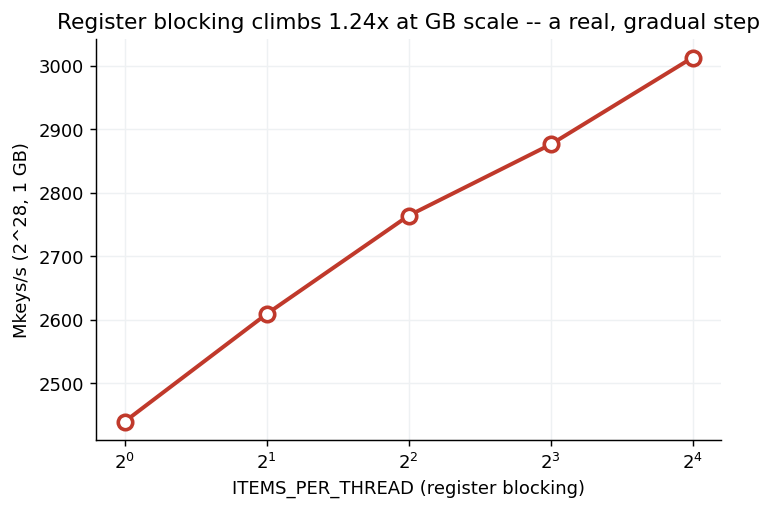

The merge-tuning arc is NOT flat: structural/data-layout opts hold on modern HW.


In [7]:
# register-blocking ablation: rebuild merge sort with IPT 1..16 and sort 1 GB
res = {}
for ipt in [1, 2, 4, 8, 16]:
    sh(f"cd demo6_mergesort && nvcc -O3 -std=c++17 -arch=sm_89 -DIPT={ipt} -o /tmp/m{ipt} merge_ablation.cu")
    res[ipt] = grab(sh(f"/tmp/m{ipt} 28 6", cwd=f"{ROOT}/demo6_mergesort"), r"([\d.]+)\s*Mkeys/s")
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(list(res), list(res.values()), "o-", color=MERGE, lw=2.2, ms=8, mfc="white", mew=2)
ax.set_xscale("log", base=2); ax.set_xlabel("ITEMS_PER_THREAD (register blocking)")
ax.set_ylabel("Mkeys/s (2^28, 1 GB)")
lo, hi = res[1], res[16]
ax.set_title(f"Register blocking climbs {hi/lo:.2f}x at GB scale -- a real, gradual step")
plt.show()
print("The merge-tuning arc is NOT flat: structural/data-layout opts hold on modern HW.")

## 6. The kernel is ~10%  (~6 min)

> **Demo** `demo3_rugpull` &middot; **in:** 2^20 keys wrapped in a per-iteration allocate/copy/sort/copy/free loop &middot; **out:** per-iteration ms for naive vs pool vs graph &middot; **algorithm:** the same v3 sort, with cudaMalloc vs cudaMallocAsync vs a captured CUDA graph &middot; **why:** the kernel is unchanged across all three -- it shows allocation/orchestration, not the kernel, dominates.

Take the best hand-rolled sort and wrap it the way a query stage actually runs: allocate, copy in, sort, copy out, free -- every iteration. The kernel never changes, yet per-iteration time swings wildly. `cudaMalloc`/`cudaFree` are synchronous driver calls; a stream-ordered pool (`cudaMallocAsync`) and a CUDA graph claw the time back -- none of it by touching the kernel.

```cpp
for (int i = 0; i < N; ++i) {
  cudaMalloc(&d_in, bytes);  cudaMalloc(&d_out, bytes);   // synchronous: serialize device
  cudaMemcpyAsync(d_in, h, bytes, H2D, s);
  sort(d_in, n, s);
  cudaMemcpyAsync(h, d_in, bytes, D2H, s);
  cudaFree(d_in);  cudaFree(d_out);                       // synchronous too
}
// the fix, same kernel: cudaMallocAsync(&d,bytes,s) / cudaFreeAsync(d,s)  (+ a CUDA graph)
```

**Guess first** 🎲 -- the *identical* sort kernel, but `cudaMalloc`/`Free` every iteration vs `cudaMallocAsync`: how much does *just the allocator* cost?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>cudaMalloc per iteration</b><pre>cudaMalloc(&amp;d, bytes);
sort(d, n, s);
cudaFree(d);</pre></td><td style="width:50%;vertical-align:top"><b>cudaMallocAsync (pool)</b><pre>cudaMallocAsync(&amp;d, bytes, s);
sort(d, n, s);
cudaFreeAsync(d, s);</pre></td></tr></table>

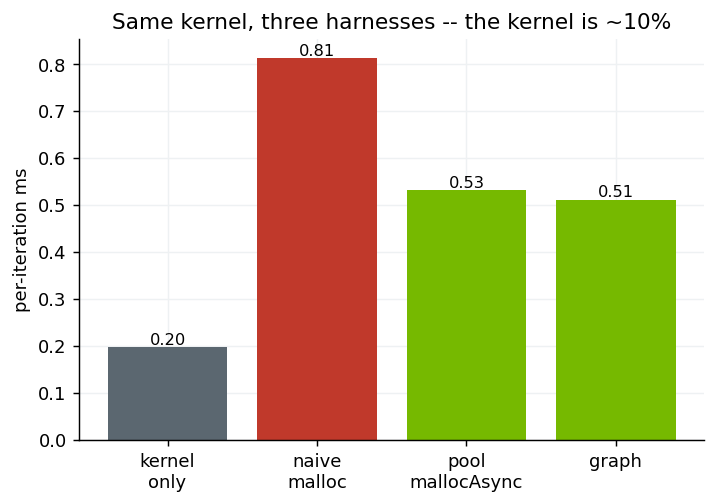

In [8]:
H = ["naive", "pool", "graph"]
outs = {h: sh(f"./{h}_harness 20 200", cwd=f"{ROOT}/demo3_rugpull") for h in H}
pit = {h: grab(outs[h], r"per-iter\s*:\s*([\d.]+)") for h in H}
kon = grab(outs["naive"], r"kernel-only\s*:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.bar(["kernel\nonly", "naive\nmalloc", "pool\nmallocAsync", "graph"], [kon, pit["naive"], pit["pool"], pit["graph"]],
       color=[CPU, MERGE, GPU, GPU])
ax.set_ylabel("per-iteration ms"); ax.set_title("Same kernel, three harnesses -- the kernel is ~10%")
for i, v in enumerate([kon, pit["naive"], pit["pool"], pit["graph"]]): ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.show()

## Closing: the library is a frozen cost-model decision tree  (~3 min)

Everything pointed one way. The chip is a **bandwidth machine you keep fed by hiding latency with concurrency**; on top of that, `thrust::sort` picks radix-vs-merge by *type* at compile time, and CUB ships *both* sorts (and both an atomic and a sort-based histogram). The experts didn't find *the* answer -- they encoded the **question** and a chooser, because the right choice is a function of the input and the chip.

So the one sentence to leave with: **compute the cost model first.** Bytes moved, passes, latency vs concurrency, where the data lives, how you access it -- that arithmetic selects the algorithm, tells you when to stop tuning, and tells you which library call to make. On a GPU, that is the program; the kernel is a detail.

**The payoff.** Open CUB's `block_merge_sort.cuh` now. The per-thread register sorting-network, the shared-memory `MergePath` merge, the `ITEMS_PER_THREAD` blocking -- you just watched each one in isolation and guessed at its cost. You can *read* it. That is what an hour of golf buys: not that you can write GEMM, but that you can read the cost-model decisions in the code you already depend on.